Partie 1 : Mission 1

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('DatasetChurn.csv')
print(df.head())

   age  tenure_months  monthly_spend  num_complaints  is_premium  churn
0   56             53          19.56               1           0      0
1   69             44          79.42               0           1      0
2   46             44          46.05               2           0      0
3   32              5          58.02               3           1      0
4   60             39          78.59               2           1      0


In [21]:
# Aperçu général

print("Dimensions du dataset :", df.shape)

print("\nTypes de variables :")

print(df.dtypes)


Dimensions du dataset : (500, 6)

Types de variables :
age                 int64
tenure_months       int64
monthly_spend     float64
num_complaints      int64
is_premium          int64
churn               int64
dtype: object


In [22]:
# Audit des valeurs manquantes

missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100



missing_df = pd.DataFrame({

    "Nb valeurs manquantes": missing_values,

    "% valeurs manquantes": missing_percentage

}).sort_values(by="% valeurs manquantes", ascending=False)
print("\n=== Audit des valeurs manquantes ===")

print(missing_df)






=== Audit des valeurs manquantes ===
                Nb valeurs manquantes  % valeurs manquantes
age                                 0                   0.0
tenure_months                       0                   0.0
monthly_spend                       0                   0.0
num_complaints                      0                   0.0
is_premium                          0                   0.0
churn                               0                   0.0


In [23]:
# Recherche de doublons

print("\n=== Vérification des doublons ===")

print("Nombre de doublons :", df.duplicated().sum())



=== Vérification des doublons ===
Nombre de doublons : 0


In [24]:
df['churn'].value_counts()

churn
0    406
1     94
Name: count, dtype: int64

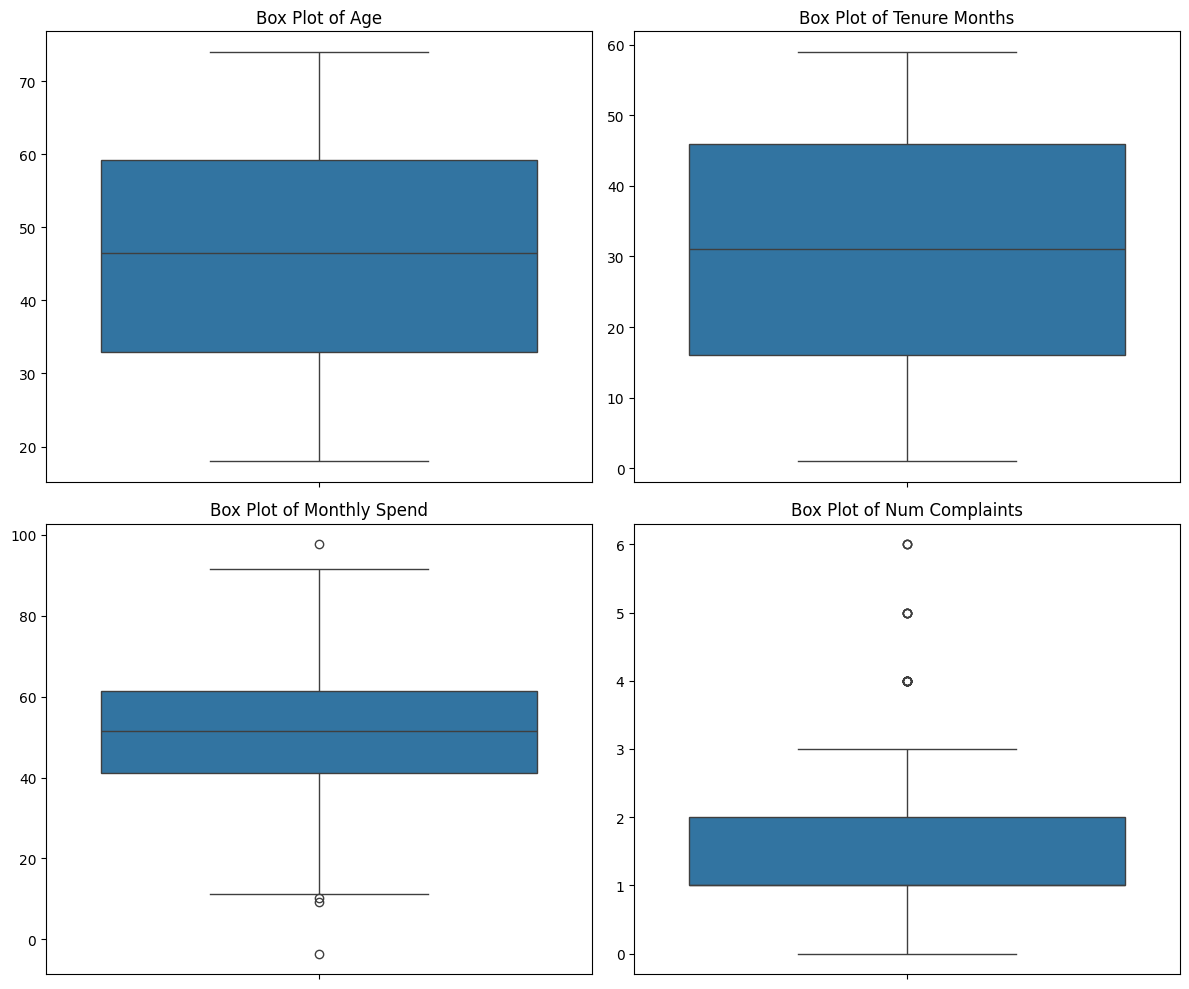

In [25]:
numerical_columns = ['age', 'tenure_months', 'monthly_spend', 'num_complaints']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten() # Flatten the 2x2 array of axes for easier iteration

for i, column in enumerate(numerical_columns):
    sns.boxplot(y=df[column], ax=axes[i])
    axes[i].set_title(f'Box Plot of {column.replace("_", " ").title()}')
    axes[i].set_ylabel('') # Remove y-label to avoid clutter, title is sufficient

plt.tight_layout()
plt.show()

In [26]:
df.describe()

,age,tenure_months,monthly_spend,num_complaints,is_premium,churn
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,46.266000,30.710000,51.095800,1.474000,0.334000,0.188000
std,16.187629,17.092636,15.811031,1.184961,0.472112,0.391103
min,18.000000,1.000000,-3.520000,0.000000,0.000000,0.000000
25%,33.000000,16.000000,41.050000,1.000000,0.000000,0.000000
50%,46.500000,31.000000,51.540000,1.000000,0.000000,0.000000
75%,59.250000,46.000000,61.432500,2.000000,1.000000,0.000000
max,74.000000,59.000000,97.620000,6.000000,1.000000,1.000000


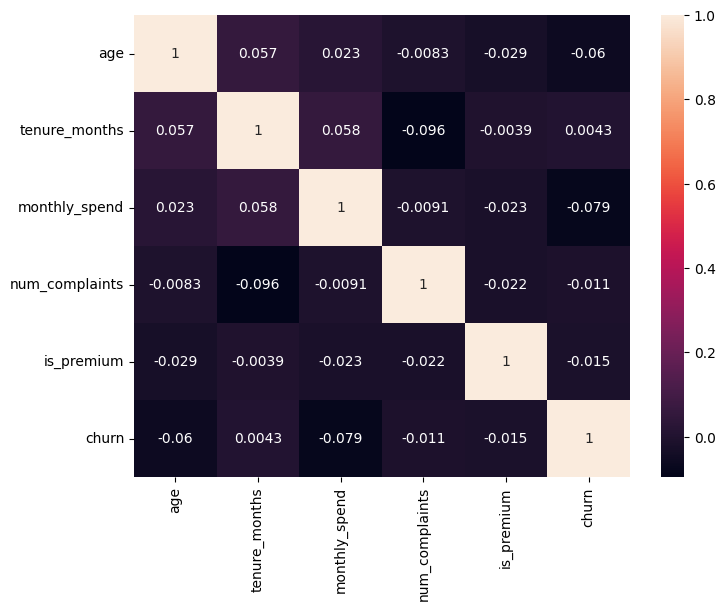

In [27]:
# Matrice de corrélation

import seaborn as sns

corr_df = df.corr(method="pearson")

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True)
plt.show()

Partie 1 : Mission 2

In [28]:
#Séparation du jeu de test et de train

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['churn'])
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Entrainement du modèle

model = LogisticRegression()
model.fit(X_train, y_train)

#Prédictions en se basant sur le modèle

y_pred = model.predict(X_test)              # classes 0/1
y_proba = model.predict_proba(X_test)[:,1]  # probabilités pour classe 1

# Métriques du modèle

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1-score :", f1)
print("AUC-ROC :", auc)



Accuracy : 0.84
Precision : 0.0
Recall : 0.0
F1-score : 0.0
AUC-ROC : 0.5647321428571429


C:\Users\soupr\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [30]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Entrainement du modèle

model = XGBClassifier()
model.fit(X_train, y_train)

# Prédictions en se basant sur le modèle

y_pred = model.predict(X_test)              # classes 0/1
y_proba = model.predict_proba(X_test)[:,1]  # probabilités pour classe 1

# Métriques sur le modèle

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1-score :", f1)
print("AUC-ROC :", auc)


Accuracy : 0.76
Precision : 0.16666666666666666
Recall : 0.125
F1-score : 0.14285714285714285
AUC-ROC : 0.4598214285714286


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Entrainement du modèle

model = RandomForestClassifier()
model.fit(X_train, y_train)

# Prédictions en se basant sur le modèle

y_pred = model.predict(X_test)              # classes 0/1
y_proba = model.predict_proba(X_test)[:,1]  # probabilités pour classe 1

# Métriques du modèle

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1-score :", f1)
print("AUC-ROC :", auc)


Accuracy : 0.81
Precision : 0.0
Recall : 0.0
F1-score : 0.0
AUC-ROC : 0.44084821428571425


In [32]:
import pandas as pd

# Liste pour stocker les résultats
results = []

# Liste des modèles et leurs noms pour l'affichage
models = [
    ('Logistic Regression', LogisticRegression()),
    ('XGBoost', XGBClassifier()),
    ('Random Forest', RandomForestClassifier()),
]

for name, model_instance in models:
    # Entraînement
    model_instance.fit(X_train, y_train)

    # Prédictions
    y_p = model_instance.predict(X_test)
    y_prob = model_instance.predict_proba(X_test)[:, 1]

    # Calcul des métriques
    results.append({
        'Modèle': name,
        'Accuracy': accuracy_score(y_test, y_p),
        'Precision': precision_score(y_test, y_p, zero_division=0),
        'Recall': recall_score(y_test, y_p),
        'F1-score': f1_score(y_test, y_p),
        'AUC-ROC': roc_auc_score(y_test, y_prob)
    })

# Création du DataFrame comparatif
df_comparison = pd.DataFrame(results)
display(df_comparison)

,Modèle,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,Logistic Regression,0.84,0.000000,0.000,0.000000,0.564732
1,XGBoost,0.76,0.166667,0.125,0.142857,0.459821
2,Random Forest,0.81,0.000000,0.000,0.000000,0.482143


Partie 2 Mission 3

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Instantiate the model with balanced class weights
model_balanced = LogisticRegression(class_weight='balanced', random_state=42)

# Fit the model on the scaled training data
model_balanced.fit(X_train, y_train)

# Make predictions on the test set
y_pred_balanced = model_balanced.predict(X_test)

# Calculate metrics
lr_balanced_metrics = {
    'Modèle': 'Logistic Regression (Balanced)',
    'Strategy': 'Class Weight Balanced',
    'Accuracy': accuracy_score(y_test, y_pred_balanced),
    'Precision': precision_score(y_test, y_pred_balanced, zero_division=0),
    'Recall': recall_score(y_test, y_pred_balanced),
    'F1-score': f1_score(y_test, y_pred_balanced)
}

# Display the results
for metric, value in lr_balanced_metrics.items():
    print(f"{metric}: {value}")

Modèle: Logistic Regression (Balanced)
Strategy: Class Weight Balanced
Accuracy: 0.57
Precision: 0.2
Recall: 0.5625
F1-score: 0.29508196721311475


In [34]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Définition du modèle
log_model = LogisticRegression(max_iter=1000)

# Définition de la grille d’hyperparamètres
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced']
}

# Mise en place de GridSearch
grid_search = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

#  Entrainement
grid_search.fit(X_train, y_train)

# Afficher les meilleurs paramètres
print("Meilleurs paramètres:", grid_search.best_params_)

# Prédictions
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Évaluation
print(classification_report(y_test, y_pred))

Meilleurs paramètres: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
              precision    recall  f1-score   support

           0       0.87      0.57      0.69        84
           1       0.20      0.56      0.30        16

    accuracy                           0.57       100
   macro avg       0.54      0.57      0.49       100
weighted avg       0.77      0.57      0.63       100



C:\Users\soupr\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


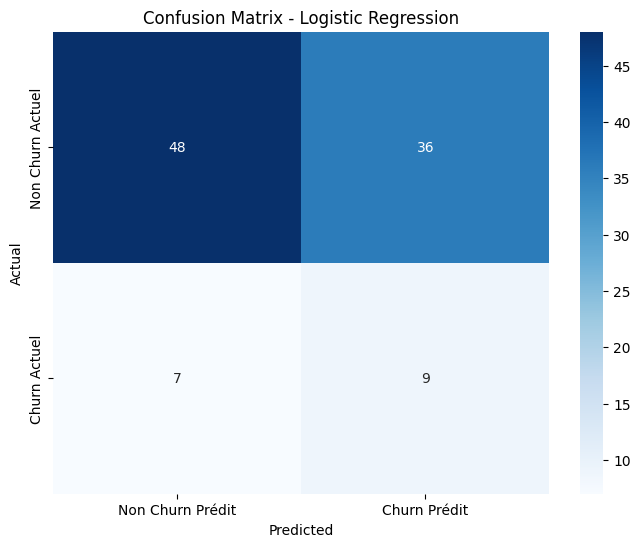

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calcul de la matrice de confusion
# On utilise y_test (réel) et y_pred (prédictions du LogisticRegression)
cm = confusion_matrix(y_test, y_pred)

# Visualisation de la matrice de confusion

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non Churn Prédit', 'Churn Prédit'],
            yticklabels=['Non Churn Actuel', 'Churn Actuel'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

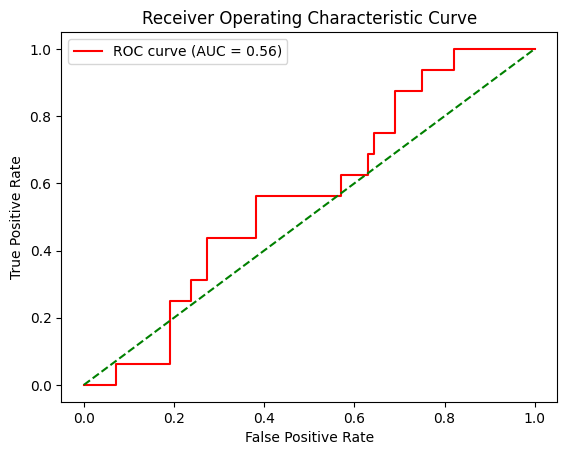

In [36]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

def plot_roc_curve(fper, tper, roc_auc_best):
    plt.plot(fper, tper, color="red", label=f'ROC curve (AUC = {roc_auc_best:.2f})')
    plt.plot([0, 1], [0, 1], color="green", linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic Curve")
    plt.legend()
    plt.show()

y_proba_best = best_model.predict_proba(X_test)[:, 1]
fper, tper, thresholds = roc_curve(y_test, y_proba_best)
roc_auc_best = roc_auc_score(y_test, y_proba_best)
plot_roc_curve(fper, tper, roc_auc_best)

In [37]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score

# Metrics pour la Logistic Regression model initiale (sans specific class_weight ou GridSearchCV) 
initial_lr_pred = model.predict(X_test) 
initial_lr_proba = model.predict_proba(X_test)[:, 1]

initial_lr_metrics_recalc = {
    'Modèle': 'Logistic Regression (Base)',
    'Accuracy': accuracy_score(y_test, initial_lr_pred),
    'Precision': precision_score(y_test, initial_lr_pred, pos_label=1, zero_division=0),
    'Recall': recall_score(y_test, initial_lr_pred, pos_label=1),
    'F1-score': f1_score(y_test, initial_lr_pred, pos_label=1),
    'AUC-ROC': roc_auc_score(y_test, initial_lr_proba)
}

# Recalcul des métriques pour GridSearchCV Optimized Logistic Regression (best_model) ---
precision_optimized_lr = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
recall_optimized_lr = recall_score(y_test, y_pred, pos_label=1)
f1_optimized_lr = f1_score(y_test, y_pred, pos_label=1)
auc_optimized_lr = roc_auc_best 

# Metrique pour Logistic Regression avec 'class_weight=balanced'-
lr_optimized_metrics_from_gridsearch = {
    'Modèle': 'Logistic Regression (Optimisé GridSearchCV - incl. class_weight)',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_optimized_lr, 
    'Recall': recall_optimized_lr,
    'F1-score': f1_optimized_lr,
    'AUC-ROC': auc_optimized_lr
}

#Metrique pour le précédent 'Logistic Regression (Balanced)' sans GridSearchCV 
lr_balanced_metrics_explicit = {
    'Modèle': 'Logistic Regression (Class Weight Balanced - No GridSearchCV)',
    'Accuracy': lr_balanced_metrics['Accuracy'], 
    'Precision': lr_balanced_metrics['Precision'], 
    'Recall': lr_balanced_metrics['Recall'],
    'F1-score': lr_balanced_metrics['F1-score'],
    'AUC-ROC': roc_auc_score(y_test, model_balanced.predict_proba(X_test)[:,1]) 
}

# Create d'un nouveau DataFrame pour comparer les trois modèles (Base, Class Weight Balanced, GridSearchCV Optimized)
focused_comparison_df = pd.DataFrame([
    initial_lr_metrics_recalc,
    lr_balanced_metrics_explicit,
    lr_optimized_metrics_from_gridsearch
])

print("\n=== Tableau Comparatif (Base, Class Weight, GridSearchCV) ===")
display(focused_comparison_df.round(4))


=== Tableau Comparatif (Base, Class Weight, GridSearchCV) ===


,Modèle,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,Logistic Regression (Base),0.81,0.0,0.0000,0.0000,0.4408
1,Logistic Regression (Class Weight Balanced - N...,0.57,0.2,0.5625,0.2951,0.5536
2,Logistic Regression (Optimisé GridSearchCV - i...,0.57,0.2,0.5625,0.2951,0.5632
